# Week 3 hand-in: Consumption

**Macroeconomics B, Chapter 16**

By the end of this notebook you will be able to:
1. Compute MPC and APC in a Keynesian consumption function.
2. Solve a two-period consumption problem and verify the closed-form solution numerically.
3. Decompose the effect of a real interest-rate change into a tilt component and a wealth component.
4. Translate a mortgage cash-flow shock into PIH and constrained consumption responses.
5. Compare the consumption effect of temporary and permanent income shocks under the PIH.
6. Estimate the comovement of consumption growth and disposable-income growth in US data.

**Submission.** Rename this file to `week03_consumption_GROUPNAME.ipynb` and submit. The notebook must run from a clean kernel without errors.

**Group information.** Write the names and KU ID numbers of all group members in the cell below.

Mikkel Dahl : xdg178

**Table of contents**<a id='toc0_'></a>
- 1. [Current income and the Keynesian benchmark](#toc1_)
- 2. [Two-period consumption and the real interest rate](#toc2_)
- 3. [Cash-flow exposure and borrowing constraints](#toc3_)
- 4. [Temporary versus permanent income shocks](#toc4_)
- 5. [Real data: consumption, income and saving](#toc5_)
- 6. [Your economic take-away](#toc6_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Global plot settings
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})

# Reproducibility
rng = np.random.default_rng(2025)

In [2]:
# Plot functionality
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Line:
    label: str
    xx: np.ndarray
    yy: np.ndarray
    own_axis: bool = False
    color: Optional[str] = None
    kwargs: dict = field(default_factory=dict)

def plot(lines: list[Line],title: str, xlabel: str, ylabel: str, show_legend: Optional[bool] = None, kwargs = {}):
    fig, ax = plt.subplots()
    ax_own = None
    plotted_lines = []
    for line in lines: 
        line_ax = ax
        if line.own_axis:
            if ax_own is None:
                ax_own = ax.twinx()
            line_ax = ax_own
        plot_kwargs = line.kwargs.copy()
        if line.color is not None:
            plot_kwargs["color"] = line.color
        plotted_lines.extend(line_ax.plot(line.xx,line.yy,label=line.label,**plot_kwargs))
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ax_own is not None:
        ax_own.set_ylabel("Own axis")
    ax.set_title(title)

    if show_legend == True:
        ax.legend(handles=plotted_lines)

    plt.show()


## 1. <a id='toc1_'></a>[Current income and the Keynesian benchmark](#toc0_)

This part implements $C = \bar C + b Y^d$ and checks what it predicts for the MPC and the APC. Use $\bar C = 200$ and $b = 0.75$ throughout.

**Task 1.1.** Plot consumption against disposable income for $Y^d \in [100, 1200]$. Label the axes and add a short title.

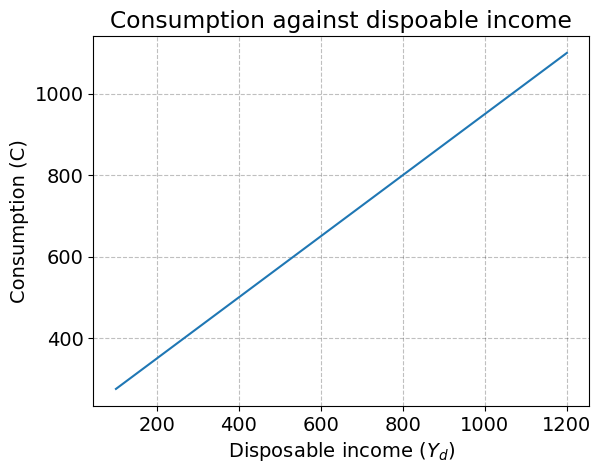

In [3]:
# write your code here

# Def of consumption
def consumption(Y_d: np.ndarray, b: float = 0.75, C_hat: float = 200) -> np.ndarray:
    return Y_d*b+C_hat

# Generating interval to align with assignment
Y_d = np.arange(100,1201,1)
assert Y_d[0] == 100 and Y_d[-1]==1200, f"Mismatch:  First: {Y_d[0]}, Last: {Y_d[-1]}" 

# Calculation
C = consumption(Y_d)

# Plotting 
trend = Line(
    label="Consumption C",
    xx=Y_d,
    yy=C,
)
plot([trend],"Consumption against dispoable income",'Disposable income $(Y_d)$','Consumption (C)')


**Task 1.2.** Compute the MPC and the APC at $Y^d \in \{400, 600, 800, 1000\}$ and display the result in a small table.

In [4]:
# Define MPC and APC
def APC(C: np.ndarray, Y_d: np.ndarray):
    return C/Y_d

def MPC(b: float = 0.75):
    return b

# Do calculations & Create table
Y_d = np.arange(400,1200,200)
C = consumption(Y_d)
df = pd.DataFrame(
    {
       "Disposable income (Y_d)": Y_d,
       "APC": APC(C,Y_d), 
       "MPC": MPC()
    }
)

# Show table
print(df)
# print(df.to_latex(index=False))

   Disposable income (Y_d)       APC   MPC
0                      400  1.250000  0.75
1                      600  1.083333  0.75
2                      800  1.000000  0.75
3                     1000  0.950000  0.75


**Task 1.3.** In two or three sentences, explain why the APC prediction is useful in the cross-section but problematic for long-run aggregate data.

#### Answer: Task 1.3 

APC prediction is useful in crossection, because it fits the emperical evidence of lower APC in richer households compared to poorer. However, it is problemamtic for long run aggregate, because it predicts as shown in the table above, that as the dispobable incomce increases, the APC decreases, while the emperics shows a constant APC. 

## 2. <a id='toc2_'></a>[Two-period consumption and the real interest rate](#toc0_)

This part turns the lecture equations into functions. You use CRRA preferences to compute $C_1$, $C_2$ and saving, then decompose the effect of a real interest-rate increase, then verify your closed-form solution numerically.

Key equations:
$$
H_1 = Y^d_1 + \frac{Y^d_2}{1+r}, \qquad
C_1 = \theta(V_1 + H_1), \qquad
\theta = \frac{1}{1 + (1+\phi)^{-\sigma} (1+r)^{\sigma - 1}}.
$$
Baseline parameters: $V_1 = 20$, $Y^d_1 = 250$, $Y^d_2 = 320$, $r = 0.03$, $\phi = 0.03$, $\sigma = 0.8$.

**Task 2.1.** Implement functions for human wealth $H_1$, the CRRA consumption share $\theta$, and the two-period allocation. The allocation function should return $C_1$, $C_2$, total wealth $W = V_1 + H_1$, and period-1 saving $S_1 = V_1 + Y^d_1 - C_1$.

In [5]:
V_1_B, Y_1_D_B, Y_2_D_B, R_B, PHI_B, SIGMA_B = 20, 250, 320, 0.03, 0.03, 0.8
import math
# write your code here
def H_1(Y_1_d: float,Y_2_d: float,r=R_B):
    return Y_1_d + Y_2_d/(1+r)

def C_1(V_1: float,H_1: float,Theta: float):
    return Theta*(V_1+H_1)

def C_2(
    C1: np.ndarray,
    r: float = R_B,
    V1: float = V_1_B,
    H1: float = H_1(Y_1_D_B, Y_2_D_B, R_B),
) -> np.ndarray:
    return (1 + r) * (V1 + H1 - C1)

# def C_2_tilt(C_1,r,phi,sigma):
#    return math.pow(((1+r)/1+phi),sigma)*C_1

def thetaFunc(r: float = R_B, phi: float = PHI_B, sigma: float = SIGMA_B):
    return 1/(1+math.pow(1+phi,-sigma)*math.pow(1+r,sigma-1))

def allocation(V_1 = V_1_B, Y_1_d = Y_1_D_B, Y_2_d = Y_2_D_B, r = R_B, phi=PHI_B, sigma = SIGMA_B, w_fixed= None):
    if w_fixed is not None:
        w = w_fixed
        h1 = w_fixed - V_1
    else:
        h1 = H_1( Y_1_d,Y_2_d,r)
        w = V_1 + h1

    theta = thetaFunc(r,phi,sigma)
    c1 = C_1(V_1,h1,theta)
    c2 = C_2(c1,r,V_1,h1)
    
    s1 = V_1+Y_1_d - c1

    return c1,c2,w,s1



**Task 2.2.** Compute $C_1$, $C_2$, total wealth and period-1 saving at the baseline parameters. Is the household saving or borrowing in period 1? Explain in one sentence why.

In [6]:
# write your code here

c1,c2,w,s1 = allocation()
print(
    f"Consumption (c1): {c1}\n"
    f"Future consumption (c2): {c2}\n"
    f"Total wealth (w): {w}\n"
    f"Savings (s1): {s1}"
)

Consumption (c1): 294.6305418719212
Future consumption (c2): 294.63054187192114
Total wealth (w): 580.6796116504854
Savings (s1): -24.630541871921196


The total savings in the present term $S_1$ is -88.1842. Since the savings are negative, the households are borrowing.

**Task 2.3.** Raise the real interest rate from $r = 0.03$ to $r = 0.07$. Compute three numbers: (i) the total change in $C_1$, (ii) the change holding total wealth fixed at the initial value (the tilt component), and (iii) the remaining wealth effect. Briefly explain why these components can have different signs.

In [7]:
# write your code here
R_HIGH = 0.07
c1_r, c2_r, w_r, s1_r = allocation(r=R_HIGH)
print(
    f"Values for r = {R_HIGH}:\n"
    f"Consumption (c1): {c1_r}\n"
    f"Future consumption (c2): {c2_r}\n"
    f"Total wealth (w): {w_r}\n"
    f"Savings (s1): {s1_r}\n"
)

# i
c1_d =  c1_r - c1 
print(c1_r)
print("Consumption Delta", c1_d)
# ii
c1_wf, c2_wf, w_wf, s1_wf = allocation(r=R_HIGH,w_fixed=w)
print(c1_wf)
c1_wf_d = c1_wf - c1
print("Consumption Delta with fixed total wealth", c1_wf_d)
# iii
# reamaining effect c1_d - c1_r = Total effect
# c1 - c1_r = titl effect
# remaining effecit = total effect - title effect
c1_d_re = c1_d - c1_wf_d
print("Consomuption delta: remaining effect: ",c1_d_re)

Values for r = 0.07:
Consumption (c1): 289.82138940799854
Future consumption (c2): 298.7911133334417
Total wealth (w): 569.0654205607477
Savings (s1): -19.821389407998538

289.82138940799854
Consumption Delta -4.809152463922658
295.73642285909267
Consumption Delta with fixed total wealth 1.1058809871714743
Consomuption delta: remaining effect:  -5.915033451094132


**i)**
Sign: Negative

An increase in the rental rate, causes the present value of the human wealth to decrease, thus decreasing the the total consumption causing a negative change in consumption.

**ii)**
Sign: Positive 

If we hold the change in the human wealth fixed, the increased rental rate, increases the current consumption. As the rental rate increasees, so does the discounted marginal utility of consumption, leading to higher current consumption and a positive sign, according to The Keynes-Ramsey logic. 

**iii)**
Sign: Negative

The remaining effect is negative and larger than the total change in consumption, as it contain effect of the increased consumption from the previously described effect. 

**Task 2.4.** Plot $C_1$ as a function of $r \in [0, 0.10]$ for $\sigma = 0.5$, $\sigma = 1.0$ and $\sigma = 1.5$, keeping the other baseline parameters fixed. Explain in two sentences how the intertemporal elasticity of substitution changes the response.

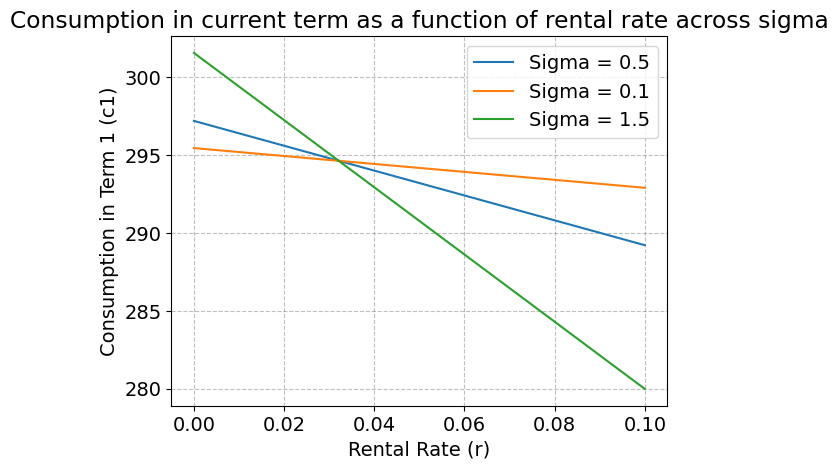

In [8]:
from itertools import product

r_l = [0,0.1]
sigma_l = [0.5,0.1,1.5]
lines = []

for sigma in sigma_l:
    c1_l = []
    for r in r_l:
        c1 = allocation(r=r,sigma=sigma)[0]
        c1_l.append(c1)
    lines.append(
        Line(
            label=f"Sigma = {sigma}",
            xx=np.array(r_l),
            yy=np.array(c1_l)
            )
    ) 

# Show plot
plot(
    lines=lines,
    title="Consumption in current term as a function of rental rate across sigma", 
    xlabel="Rental Rate (r)",
    ylabel="Consumption in Term 1 (c1)",
    show_legend=True
    ) 

_Write your explanation here._

**Task 2.5. Numerical cross-check.** Verify the closed-form $C_1$ at the baseline parameters by computing lifetime utility on a fine grid of candidate $C_1$ values and locating the maximiser numerically. Use
$$
u(C) = \frac{C^{1 - 1/\sigma}}{1 - 1/\sigma}, \qquad
C_2(C_1) = (1+r)\,(V_1 + H_1 - C_1), \qquad
U(C_1) = u(C_1) + \frac{1}{1+\phi}\,u(C_2(C_1)).
$$
Report the closed-form $C_1$, the grid-search $C_1$, and their absolute difference. The two should agree to within 0.05. Briefly say what would have to be wrong in your code if they did not.

In [9]:
def u(C: np.ndarray, sigma: float = SIGMA_B) -> np.ndarray:
    if sigma == 1:
        raise ValueError("sigma = 1 makes the denominator zero.")

    C = np.asarray(C, dtype=float)
    return C ** (1 - 1 / sigma) / (1 - 1 / sigma)


def u_prime(C: np.ndarray, sigma: float = SIGMA_B) -> np.ndarray:
    C = np.asarray(C, dtype=float)
    return C ** (-1 / sigma)



def U(
    C1: np.ndarray,
    sigma: float = SIGMA_B,
    r: float = R_B,
    V1: float = V_1_B,
    H1: float = H_1(Y_1_D_B, Y_2_D_B, R_B),
    phi: float = PHI_B,
) -> np.ndarray:
    return u(C1, sigma) + (1 / (1 + phi)) * u(C_2(C1, r, V1, H1), sigma)

def U_w_print(
    C1: np.ndarray,
    sigma: float = SIGMA_B,
    r: float = R_B,
    V1: float = V_1_B,
    H1: float = H_1(Y_1_D_B, Y_2_D_B, R_B),
    phi: float = PHI_B,
):
    c1_u = u(C1, sigma)
    c2_u = (1 / (1 + phi)) * u(C_2(C1, r, V1, H1), sigma)
    return c1_u,c2_u 


In [10]:
c1,c2,w,s1 = allocation()
print("c1", c1)
print("c2", c2)

# General Euler equation: u'(C1) = ((1+r)/(1+phi))u'(C2).
# At the baseline r = phi, this reduces to u'(C1) = u'(C2).
marginal_utility_c1 = u_prime(c1)
marginal_utility_c2 = u_prime(c2)
euler_residual = marginal_utility_c1 - ((1 + R_B) / (1 + PHI_B)) * marginal_utility_c2

print("u'(c1)", marginal_utility_c1)
print("u'(c2)", marginal_utility_c2)
print("Euler residual", euler_residual)


c1 294.6305418719212
c2 294.63054187192114
u'(c1) 0.0008192242404317576
u'(c2) 0.0008192242404317579
Euler residual -2.168404344971009e-19


In [11]:
# The following solution assumes, that the numerical solution does not know a prio the true solution, thus it is part of the problem, to give a a solution which gaurentees the required difference a prior

# Solution 1: Tenerary search w. assumptions C1 >= 0, and C1 <= W = V1 + H1
# In words: We assume that the household cannot consume more in the current than the households total wealth
# Recursive functions that stops when the diference between the bin centroids are below epsilon value of 0.05

def tenerary_search(max_c,min_c,eps=0.05, centers = None):
    if centers is None:
        centers = []
    center = np.float64(min_c + (max_c-min_c)/2)
    delta = np.array([center-eps, center+eps],dtype=np.float64)
    U_bin_centroids = U(delta)
    bin_idx = np.argmax(U_bin_centroids)    

    centers.append({
        "center": center,
        "max": max_c,
        "min": min_c,
        "max_u": U_bin_centroids[1],
        "min_u": U_bin_centroids[0],
        "direction": "increase" if bin_idx == 1 else "decrease"
    })
    if abs(max_c-min_c)< float(eps):
        return center, U_bin_centroids[bin_idx], centers
    else:
        if bin_idx == 0:
            return tenerary_search(center,min_c,eps,centers)
        else: 
            return tenerary_search(max_c, center,eps,centers)

In [12]:
# Solution 2: Numpy grid search with step size eps
def grid_search(max_c,min_c=1e-8,eps=0.05):
    grid_c1 = np.arange(min_c,max_c,eps)
    return grid_c1[np.argmax(U(grid_c1))]

In [13]:
import time
# Assumption: people cannot die with unpaid debt
true_c1,_,w,_ = allocation()
max_c = w
min_c = 0.0
eps = 0.05
grid_min_c = 1e-8

In [14]:
start = time.perf_counter()
c1_est_t,U_c1,centers = tenerary_search(max_c,min_c,eps)
end = time.perf_counter()
ternary_elapsed = end-start

start = time.perf_counter()
c1_est_g = grid_search(max_c,grid_min_c,eps)
end = time.perf_counter()
grid_elapsed = end-start

print(
    f"Analytical C1: {true_c1}\n"
    f"Tenerary Search Estimate: {c1_est_t}\n" 
    f"Tenerary estimation error: {abs(c1_est_t-true_c1)}\n"
    f"Tenerary elapsed time: {ternary_elapsed}\n"
    f"Grid Search Estimate: {c1_est_g}\n"
    f"Grid estimation error: {abs(c1_est_g-true_c1)}\n"
    f"Grid elapsed time: {grid_elapsed}\n" 
    )


Analytical C1: 294.6305418719212
Tenerary Search Estimate: 294.6459931308783
Tenerary estimation error: 0.015451258957114078
Tenerary elapsed time: 0.0002775830071186647
Grid Search Estimate: 294.65000001000004
Grid estimation error: 0.019458138078846332
Grid elapsed time: 0.00039783300599083304



## 3. <a id='toc3_'></a>[Cash-flow exposure and borrowing constraints](#toc0_)

This part connects the model to the lecture's Danish mortgage example. You compute monthly annuity mortgage payments, translate a rate increase into a present-value loss, and compare a PIH household with a constrained household. You will then build a group-specific profile and solve a small numerical inversion.

**Task 3.1.** Write a function for the monthly payment on an annuity mortgage. Use it to compute the monthly and annual payment increase for $D = 2{,}000{,}000$ DKK, $M = 25$ years, when the annual rate rises from 1 percent to 5 percent. Display the result in a small table.

#### Assumptions

This assignment, seemed a bit unclear to me. Thus i will clarify the assumptions i have used, to solve this:


1) i is the effective annual rate, meaning that: $x(1+r)^12*M = x*(1+i)^M$ and r = 

2) Downpayment happens at every month, and there is no downpayment in $t=0$ 


In [15]:
def effective_monthly_rate(i):
    return (1+i)**(1/12) - 1 

def monthly_mortgage_payment(D, M, i):
    r = effective_monthly_rate(i)
    N = M * 12
    return D * r / (1 - (1 + r) ** (-N))

payments = [monthly_mortgage_payment(2_000_000,25,i) for i in [0.01,0.05]]

pd.DataFrame({
    "Annual Rate": [0.01,0.05],
    "Monthly annuity mortage payments": payments,
    "Monthly Payment increase from 0.01": ["-", (payments[1]-payments[0])]
},
)

,Annual Rate,Monthly annuity mortage payments,Monthly Payment increase from 0.01
0,0.01,7533.326519,-
1,0.05,11562.763752,4029.437233


**Task 3.2.** Assume the higher payment lasts for 3 years. Compute the present value of the cash-flow loss at a real rate of 3 percent. Use the annuity factor
$$
A(N, r) = \sum_{j=0}^{N-1} (1+r)^{-j}.
$$

#### Solution
I will clarify some confusings and assumptions, i have used to solve this enigma of a task.

1) I am gonna to assume that tit is a fixed rate down payment, such that they must pay the the rate in which they started

2) I aassumming that that 5% rate starts from t=0,t=1,t=3 (three years), and goes down from t=4 to t=25. I 

3) I assume that cash flow loss pr t non adjusted, is equivalent to the difference in payment between the two rates 

In [16]:
# write your code here
def annuity(N, r,start=0):
    i = np.arange(N)
    pv_list = ((1/(1 + r))** i) 
    return np.sum(pv_list[start:])

# Assuming no payment in t=0, we actual have 35 payments in 3 years
monthly_loss = (payments[1]-payments[0])
ann = annuity(35,effective_monthly_rate(i=0.03), start=1)
pv_total_loss = ann*monthly_loss

print("Monthly cash flow difference", monthly_loss)
print("Yearly cash flow difference", monthly_loss*12)
print("Total cash flow difference: ", monthly_loss*35)
print("Present Value of total cash flow loss: ", pv_total_loss)

Monthly cash flow difference 4029.4372327483998
Yearly cash flow difference 48353.2467929808
Total cash flow difference:  141030.303146194
Present Value of total cash flow loss:  131259.02250857843


**Task 3.3.** Compare two households facing this PV loss:

- a **PIH household** with a 30-year horizon, who spreads the present-value loss over the remaining horizon using $\theta_{30} = 1/A(30, 0.03)$;
- a **constrained household** with MPC equal to 0.9 applied to the annual payment increase.

Report the implied annual consumption cut for each. Comment in two sentences on why the gap is so large.

In [17]:
def ucon_consumption_delta(W_delta,V_delta):
    return (W_delta+V_delta)/annuity(30,0.03)

def con_consumption_delta(MPC, annual_cost):
    return MPC*annual_cost

C_delta_con = con_consumption_delta(0.9,-12*monthly_loss)

W_delta = -pv_total_loss 
V_delta = 0
C_delta_ucon =  ucon_consumption_delta(W_delta,V_delta)


pd.DataFrame({
    "Object": ["Unconstrained C delta","Constrained C delta", "Difference"],
    "": [C_delta_ucon, C_delta_con, C_delta_con-C_delta_ucon]
})

,Object,
0,Unconstrained C delta,-6501.687483
1,Constrained C delta,-43517.922114
2,Difference,-37016.234631


The difference in change of consumption is -37016.2. For the constrained household, the increase cost must be paid out of pocket, thus consumptions suffers more greatly, which is further multiplied by the the high MPC. For the Unconstrained, the increased cost, can be offset by borrowing, thus distributing the cost over longer periods.

**Task 3.4. Group-specific household profile.** Create your own household profile by changing at least two of: debt, maturity, initial rate, new rate, horizon, or constrained MPC. Plot the PIH cut and the constrained cut for your profile alongside the baseline. In one or two sentences, explain why your profile is plausible (e.g. typical first-time buyer, household near retirement, large-mortgage urban household).

## Household profile (High Income first time buyer experiences rate increase)


| Parameter | Profile value |
|---|---:|
| Debt | 3,000,000 DKK |
| Maturity | 30 years |
| Initial rate | 1.5% |
| New rate | 5.0% |
| Horizon | 30 years |
| Constrained MPC | 0.50 |

The profile represents a high income first time buyer with a midsized morgagte and long maturity. This profile is plausisble for representing young students buying their first aparment after getting their first full time job, as they typically have high incomes and few expenses.  

0.6095482312061336


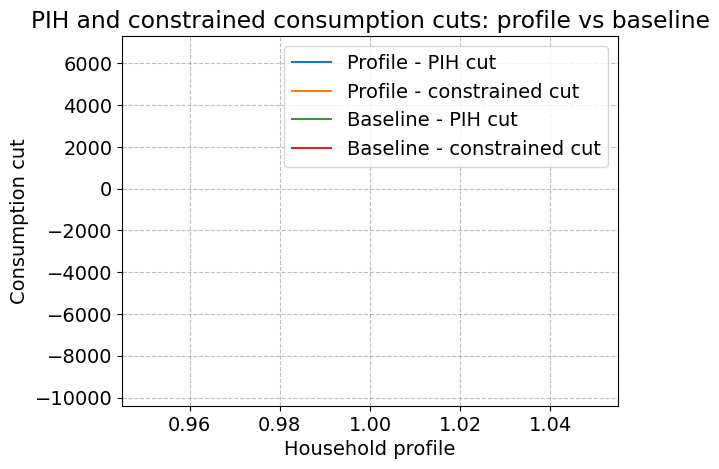

In [ ]:
# write your code here
R_init = 0.015
R_n = 0.05
M = 30
MPC_c = 0.50
dept = 3_000_000
V1 = 0


# Profile - constrained cost
payments = [monthly_mortgage_payment(dept,M,i) for i in [R_init,R_n]]
monthly_cost_change = payments[1]-payments[0]
annual_cost =  -12*monthly_cost_change
delta_c_con = con_consumption_delta(MPC_c,annual_cost)

# Profile - unconstrained
ann = annuity(35,effective_monthly_rate(i=0.03), start=1)
pv_total_loss = ann*monthly_loss
delta_c_ucon = ucon_consumption_delta(W_delta=pv_total_loss, V_delta=0) 

# Baseline - unconstrained 
delta_c_ucon_b = (allocation(r=0.04)[0] - allocation(r=0.045)[0])

# Baseline contrained
c1,c2,w,s1 = allocation(r=0.04)

# use mcp at new or old? old
delta_c_con_b = con_consumption_delta(u_prime(np.array(c1)),annual_cost)

# Plot Task 3.4: baseline vs profile
print(delta_c_ucon_b)

lines = [
    Line(
        label="Profile - PIH cut",
        xx=np.array([1]),
        yy=np.array([delta_c_ucon])
    ),
    Line(
        label="Profile - constrained cut",
        xx=np.array([1]),
        yy=np.array([delta_c_con])
    ),
    Line(
        label="Baseline - PIH cut",
        xx=np.array([1]),
        yy=np.array([delta_c_ucon_b])
    ),
    Line(
        label="Baseline - constrained cut",
        xx=np.array([1]),
        yy=np.array([delta_c_con_b])
    )
]

plot(
    lines=lines,
    title="PIH and constrained consumption cuts: profile vs baseline",
    xlabel="Household profile",
    ylabel="Consumption cut",
    show_legend=True
)


_Write your one to two sentence justification here._

**Task 3.5. Break-even constrained MPC.** For your group profile from Task 3.4, find numerically the constrained MPC $m^\ast$ at which the constrained household's annual consumption cut equals the PIH household's. Hint: a fine grid of MPC values between 0 and 1 is enough. Report $m^\ast$ to three decimals and comment in two sentences on what the size of $m^\ast$ implies about how easy or hard it is to identify constrained households empirically.

In [19]:
# write your code here

_Write your two-sentence comment here._

## 4. <a id='toc4_'></a>[Temporary versus permanent income shocks](#toc0_)

This part uses the annuity factor to show why the PIH predicts a small current response to a one-off income gain and a large response to a persistent income gain. Use $r = 0.03$ throughout.

**Task 4.1.** Implement the annuity factor $A(N, r) = \sum_{j=0}^{N-1}(1+r)^{-j}$ and the temporary MPC $\theta_N = 1/A(N, r)$. Plot $\theta_N$ for $N = 1, \ldots, 60$. Add a horizontal line at the long-horizon limit $r/(1+r)$.

In [20]:
# write your code here

**Task 4.2.** For a DKK 5,000 income increase, compare the predicted consumption response if the increase is (i) temporary and (ii) permanent. Report the numbers for $N = 5$, $N = 30$ and $N = 60$ in a table.

In [21]:
# write your code here

**Task 4.3.** Suppose 35 percent of households are constrained with MPC 0.9 and the rest follow the PIH. Compute the aggregate consumption response to the temporary DKK 5,000 increase for $N = 5$, $N = 30$ and $N = 60$. Add this column to the table from Task 4.2.

In [22]:
# write your code here

## 5. <a id='toc5_'></a>[Real data: consumption, income and saving](#toc0_)

This part uses US aggregate data to check how consumption, disposable income and saving move together. The regression coefficient is descriptive comovement, not a structural MPC. Treat it as evidence and interpret it carefully.

The provided CSV has quarterly observations of three FRED series:

- `dpi` = real disposable personal income (FRED `DPIC96`)
- `pce` = real personal consumption expenditure (FRED `PCEC96`)
- `saving_rate` = personal saving rate (FRED `PSAVERT`)

If you want, you can fetch the series directly from FRED with your own API key. The cell below loads the CSV by default.

In [23]:
# -------------------------------------------------------
# Optional FRED API setup
# Get a free key at: https://fredaccount.stlouisfed.org/apikey
# Leaving FRED_API_KEY empty falls back to the provided CSV.
# -------------------------------------------------------
FRED_API_KEY = ''
FRED_BASE = 'https://api.stlouisfed.org/fred/series/observations'
DATA_FILE = 'week03_fred_consumption.csv'


def fetch_fred(series_id, api_key, frequency=None):
    """ Download a FRED series as a pandas Series with DatetimeIndex.

    Args:
        series_id (str): FRED series identifier.
        api_key   (str): FRED API key.
        frequency (str): optional aggregation frequency such as 'q'.

    Returns:
        pd.Series: observations indexed by date.
    """
    params = {'series_id': series_id, 'api_key': api_key, 'file_type': 'json'}
    if frequency is not None:
        params['frequency'] = frequency
    r = requests.get(FRED_BASE, params=params, timeout=20)
    r.raise_for_status()
    obs = r.json()['observations']
    dates = pd.to_datetime([o['date'] for o in obs])
    values = pd.to_numeric([o['value'] for o in obs], errors='coerce')
    s = pd.Series(values.values, index=dates, name=series_id)
    return s


def load_consumption_data(api_key='', fallback_path=DATA_FILE):
    """ Load consumption data from FRED if a key is given, else from the CSV. """
    if api_key.strip() == '':
        data = pd.read_csv(fallback_path, parse_dates=['DATE'])
        data = data.set_index('DATE').sort_index()
        print(f'Loaded CSV with {len(data)} quarterly observations '
              f'from {data.index[0].date()} to {data.index[-1].date()}.')
        return data
    dpi = fetch_fred('DPIC96', api_key).rename('dpi')
    pce = fetch_fred('PCEC96', api_key).rename('pce')
    saving = fetch_fred('PSAVERT', api_key).rename('saving_rate')
    data = pd.concat([dpi, pce, saving], axis=1).resample('QE').mean().dropna()
    print(f'Fetched {len(data)} quarterly observations from FRED.')
    return data


data = load_consumption_data(FRED_API_KEY, DATA_FILE)
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'week03_fred_consumption.csv'

**Task 5.1.** Plot real disposable personal income and real personal consumption expenditure as indices with 2015Q1 = 100. Then plot APC $= PCE/DPI$ and the saving rate together (a twin axis is fine). Add a brief source note in each figure.

In [ ]:
# write your code here

**Task 5.2.** Compute quarterly log changes in consumption and disposable income. Estimate
$$
\Delta \log C_t = \alpha + \beta \, \Delta \log Y^d_t + \varepsilon_t
$$
by OLS using NumPy. Report $\hat\beta$ and a 95 percent confidence interval.

In [ ]:
# write your code here

**Task 5.3.** Repeat the estimate excluding 2020Q1 to 2021Q4. Briefly explain why this period may be special.

In [ ]:
# write your code here

_Write your two-sentence explanation here._

**Task 5.4.** Make a scatter plot of $\Delta \log C_t$ against $\Delta \log Y^d_t$ with the fitted regression line for the full sample. Explain in three or four sentences what the plot suggests and what it cannot prove.

In [ ]:
# write your code here

_Write your three to four sentence interpretation here._

## 6. <a id='toc6_'></a>[Your economic take-away](#toc0_)

Write 250 to 400 words. The narrative is graded on whether you connect mechanism to numbers, not on length. Mention:

1. one result from the two-period model, citing the specific number you obtained;
2. one result from the mortgage cash-flow experiment, citing your own group profile;
3. one result from the data section, citing your own $\hat\beta$;
4. one limitation of your analysis.

_Write your 250 to 400 word narrative here._

In [ ]:
# Optional: any extra computations for the narrative go here.